# XGBoost Pipeline — Trajectory Prediction Metrics (GAM-Style)

This notebook fits an XGBoost regressor to trajectory prediction error metrics using prepared trajectory/scene characteristics.
It mirrors the structure of `gam.ipynb`, uses a random train/validation/test split, and focuses interpretability on conditions where performance is poor vs. well.

## 1. Imports and Configuration

In [1]:
# Core libraries
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib

# Compatibility shim: matplotlib_inline expects RcParams._get in some versions.
if not hasattr(matplotlib.RcParams, "_get"):
    matplotlib.RcParams._get = matplotlib.RcParams.__getitem__

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import PartialDependenceDisplay

import xgboost as xgb
import shap

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Notebook-level config constants
DATA_PATH = Path('../../results/interpretable_model/prepared_data/prepared_data_ml_ade.csv')
TARGET_COL = None  # Optional override, e.g. 'ml_ade_log'

RANDOM_STATE = 42
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
POOR_WELL_QUANTILE = 0.20

SAVE_DIR = Path('../../results/interpretable_model/xgboost')
PLOTS_DIR = SAVE_DIR / 'plots'
TABLES_DIR = SAVE_DIR / 'tables'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

assert abs((TRAIN_RATIO + VAL_RATIO + TEST_RATIO) - 1.0) < 1e-9, 'Split ratios must sum to 1.0'

print('Imports and configuration loaded.')
print(f'DATA_PATH: {DATA_PATH}')
print(f'SAVE_DIR:  {SAVE_DIR.resolve()}')

Imports and configuration loaded.
DATA_PATH: ../../results/interpretable_model/prepared_data/prepared_data_ml_ade.csv
SAVE_DIR:  /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/xgboost


## 2. Load Prepared Data and Inspect

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape}')
print('Columns:')
print(df.columns.tolist())

display(df.head())

missing_summary = df.isna().sum().sort_values(ascending=False)
print('\nMissing values per column:')
display(missing_summary.to_frame('missing_count'))

dtype_summary = df.dtypes.astype(str).to_frame('dtype')
print('\nColumn dtypes:')
display(dtype_summary)

Dataset shape: (451, 14)
Columns:
['max_speed', 'std_speed', 'mean_acceleration', 'max_acceleration', 'path_efficiency', 'heading_change', 'has_collision', 'min_neighbor_distance', 'scene_num_agents', 'scene_bbox_area', 'scene_bbox_width', 'scene_spatial_density', 'scene_density_VEHICLE', 'ml_ade_log']


,max_speed,std_speed,mean_acceleration,max_acceleration,path_efficiency,heading_change,has_collision,min_neighbor_distance,scene_num_agents,scene_bbox_area,scene_bbox_width,scene_spatial_density,scene_density_VEHICLE,ml_ade_log
0,1.230403,0.116722,0.056417,0.404461,84.461237,112.440745,0.0,1.013903,17.0,1160.377375,40.869190,0.014650,0.005171,0.649643
1,0.218477,0.063105,0.007725,0.311925,15.733080,941.304051,0.0,3.023524,17.0,1160.377375,40.869190,0.014650,0.005171,0.140704
2,0.383437,0.099171,0.031384,0.470005,43.684220,488.173829,0.0,1.104355,50.0,1821.083675,44.533135,0.027456,0.012630,0.388765
3,1.483624,0.190256,0.051802,0.794096,95.139840,81.155053,1.0,0.426945,16.0,1230.401053,43.391608,0.013004,0.005689,0.821990
4,0.218477,0.064457,0.010995,0.311925,27.282729,946.683531,0.0,2.796330,15.0,1057.088774,37.340273,0.014190,0.005676,0.159340



Missing values per column:


,missing_count
max_speed,0
std_speed,0
mean_acceleration,0
max_acceleration,0
path_efficiency,0
heading_change,0
has_collision,0
min_neighbor_distance,0
scene_num_agents,0
scene_bbox_area,0



Column dtypes:


,dtype
max_speed,float64
std_speed,float64
mean_acceleration,float64
max_acceleration,float64
path_efficiency,float64
heading_change,float64
has_collision,float64
min_neighbor_distance,float64
scene_num_agents,float64
scene_bbox_area,float64


## 3. Resolve Target and Build Feature Matrix

In [3]:
if TARGET_COL is not None:
    assert TARGET_COL in df.columns, f'TARGET_COL={TARGET_COL} not found in dataset columns.'
    target_col = TARGET_COL
else:
    if 'ml_ade_log' in df.columns:
        target_col = 'ml_ade_log'
    elif 'ml_ade' in df.columns:
        target_col = 'ml_ade'
    else:
        target_col = df.columns[-1]

feature_cols = [c for c in df.columns if c != target_col]

# Keep only numeric features (prepared dataset is expected to be numeric-only)
non_numeric_features = [c for c in feature_cols if not np.issubdtype(df[c].dtype, np.number)]
if non_numeric_features:
    print('WARNING: Non-numeric features found and dropped:')
    print(non_numeric_features)
feature_cols = [c for c in feature_cols if c not in non_numeric_features]

model_df = df[feature_cols + [target_col]].dropna().copy()

X = model_df[feature_cols]
y = model_df[target_col]
row_ids = model_df.index.to_numpy()

print(f'Target column: {target_col}')
print(f'Number of features: {len(feature_cols)}')
print(f'Rows available for modeling: {len(model_df)}')
print(f'Feature matrix shape: {X.shape}')
print(f'Target vector shape: {y.shape}')

Target column: ml_ade_log
Number of features: 13
Rows available for modeling: 451
Feature matrix shape: (451, 13)
Target vector shape: (451,)


## 4. Train/Validation/Test Split (70/15/15, Random)

In [4]:
# First split: train vs temp (val+test)
X_train, X_temp, y_train, y_temp, id_train, id_temp = train_test_split(
    X, y, row_ids,
    test_size=(1.0 - TRAIN_RATIO),
    random_state=RANDOM_STATE,
    shuffle=True
)

# Second split: val vs test (equal halves of temp -> 15/15 overall)
X_val, X_test, y_val, y_test, id_val, id_test = train_test_split(
    X_temp, y_temp, id_temp,
    test_size=(TEST_RATIO / (VAL_RATIO + TEST_RATIO)),
    random_state=RANDOM_STATE,
    shuffle=True
)

# Validate split sizes and non-overlap
n_total = len(model_df)
n_sum = len(X_train) + len(X_val) + len(X_test)
assert n_sum == n_total, f'Split size mismatch: {n_sum} vs {n_total}'

train_set = set(id_train.tolist())
val_set = set(id_val.tolist())
test_set = set(id_test.tolist())
assert train_set.isdisjoint(val_set)
assert train_set.isdisjoint(test_set)
assert val_set.isdisjoint(test_set)

print(f'Total: {n_total}')
print(f'Train: {len(X_train)} ({len(X_train)/n_total:.2%})')
print(f'Val:   {len(X_val)} ({len(X_val)/n_total:.2%})')
print(f'Test:  {len(X_test)} ({len(X_test)/n_total:.2%})')
print('Split validation passed (sum and non-overlap).')

Total: 451
Train: 315 (69.84%)
Val:   68 (15.08%)
Test:  68 (15.08%)
Split validation passed (sum and non-overlap).


## 5. Fit XGBoost Regressor (Fixed Hyperparameters + Early Stopping)

In [5]:
XGB_CONFIG = {
    'objective': 'reg:squarederror',
    'n_estimators': 2000,
    'learning_rate': 0.03,
    'max_depth': 4,
    'min_child_weight': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.0,
    'reg_lambda': 1.0,
    'random_state': RANDOM_STATE,
}
EARLY_STOPPING_ROUNDS = 50

model = xgb.XGBRegressor(**XGB_CONFIG)

# Compatibility across xgboost versions (fit-level or param-level early stopping)
try:
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        verbose=False,
    )
except TypeError:
    model.set_params(early_stopping_rounds=EARLY_STOPPING_ROUNDS)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

best_iteration = getattr(model, 'best_iteration', None)
best_ntree_limit = getattr(model, 'best_ntree_limit', None)

print('Model fitted successfully.')
print(f'Best iteration:   {best_iteration}')
print(f'Best ntree limit: {best_ntree_limit}')

Model fitted successfully.
Best iteration:   459
Best ntree limit: None


## 6. Evaluate on Train/Val/Test (Original Scale)

In [6]:
def to_original_scale(values, col_name):
    if col_name.endswith('_log'):
        return np.expm1(values)
    return values

def evaluate_split(split_name, y_true_raw, y_pred_raw, col_name):
    y_true_orig = to_original_scale(np.asarray(y_true_raw), col_name)
    y_pred_orig = to_original_scale(np.asarray(y_pred_raw), col_name)

    return {
        'Split': split_name,
        'R²': r2_score(y_true_orig, y_pred_orig),
        'MAE': mean_absolute_error(y_true_orig, y_pred_orig),
        'RMSE': float(np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))),
    }, y_true_orig, y_pred_orig

y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)
y_pred_test = model.predict(X_test)

train_metrics, y_train_orig, y_train_pred_orig = evaluate_split('Train', y_train, y_pred_train, target_col)
val_metrics, y_val_orig, y_val_pred_orig = evaluate_split('Validation', y_val, y_pred_val, target_col)
test_metrics, y_test_orig, y_test_pred_orig = evaluate_split('Test', y_test, y_pred_test, target_col)

metrics_df = pd.DataFrame([train_metrics, val_metrics, test_metrics])
display(metrics_df)

metrics_path = TABLES_DIR / f'metrics_{target_col}.csv'
metrics_df.to_csv(metrics_path, index=False)
print(f'Metrics saved to: {metrics_path}')

,Split,R²,MAE,RMSE
0,Train,0.984481,0.049795,0.073690
1,Validation,0.755319,0.165462,0.243266
2,Test,0.805614,0.189834,0.267946


Metrics saved to: ../../results/interpretable_model/xgboost/tables/metrics_ml_ade_log.csv


## 7. Model-Fit Diagnostics (Test Set)

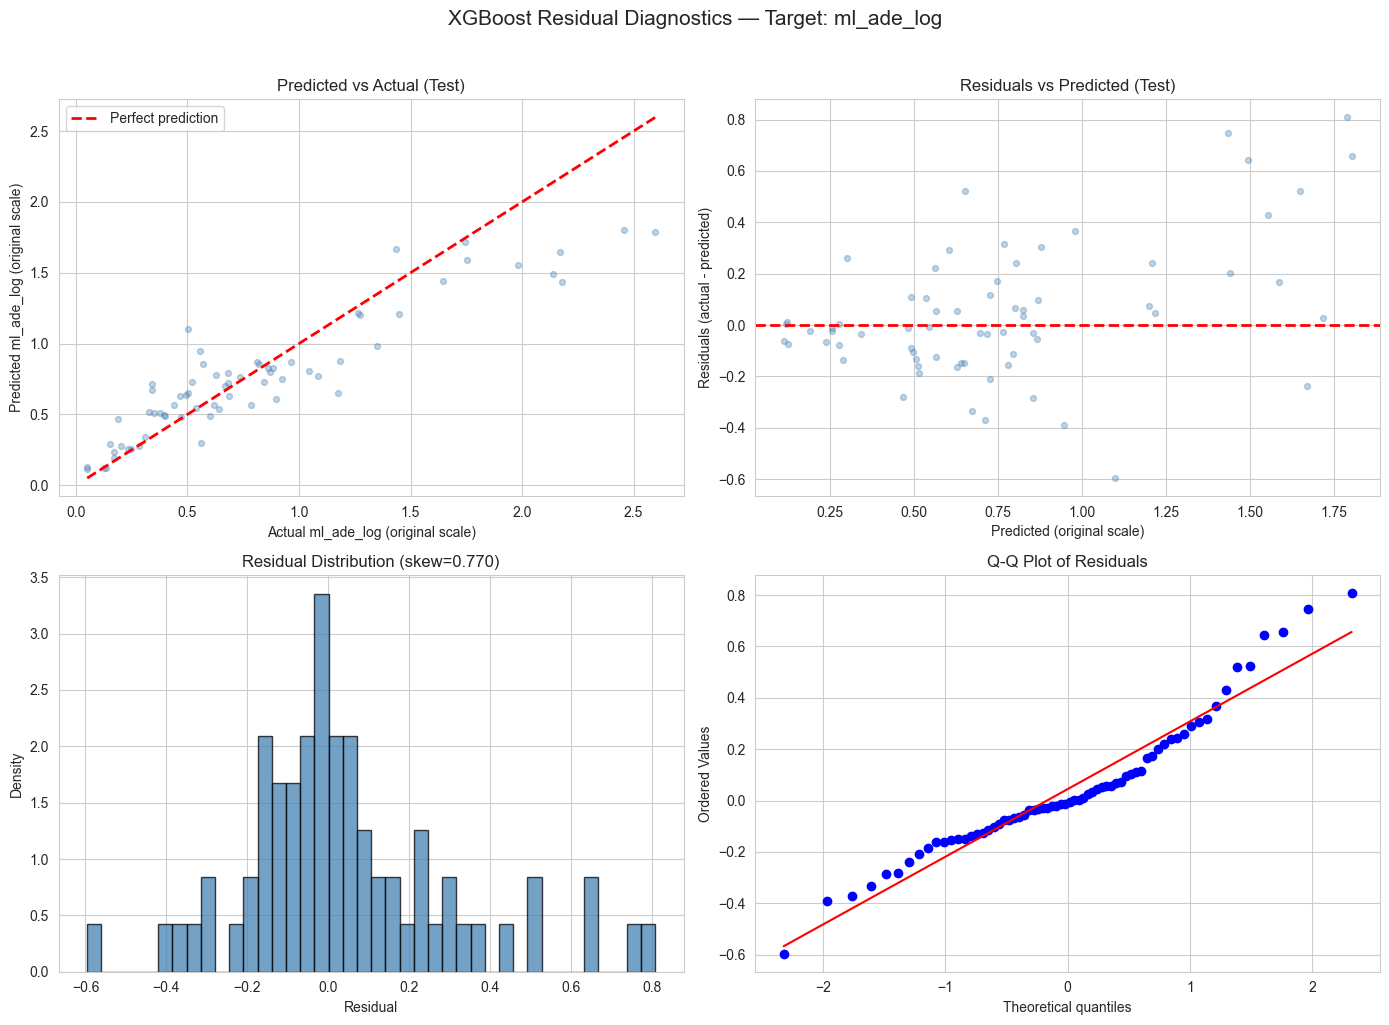

Diagnostics plot saved to: ../../results/interpretable_model/xgboost/plots/residual_diagnostics_ml_ade_log.png
Residual mean:   0.044818
Residual median: -0.008574
Residual std:    0.264171


In [7]:
residuals_test = y_test_orig - y_test_pred_orig

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Predicted vs actual
axes[0, 0].scatter(y_test_orig, y_test_pred_orig, alpha=0.35, s=18, color='steelblue')
lims = [
    min(np.min(y_test_orig), np.min(y_test_pred_orig)),
    max(np.max(y_test_orig), np.max(y_test_pred_orig)),
]
axes[0, 0].plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
axes[0, 0].set_xlabel(f'Actual {target_col} (original scale)')
axes[0, 0].set_ylabel(f'Predicted {target_col} (original scale)')
axes[0, 0].set_title('Predicted vs Actual (Test)')
axes[0, 0].legend()

# 2) Residuals vs predicted
axes[0, 1].scatter(y_test_pred_orig, residuals_test, alpha=0.35, s=18, color='steelblue')
axes[0, 1].axhline(0.0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted (original scale)')
axes[0, 1].set_ylabel('Residuals (actual - predicted)')
axes[0, 1].set_title('Residuals vs Predicted (Test)')

# 3) Residual histogram
axes[1, 0].hist(residuals_test, bins=40, density=True, alpha=0.75, color='steelblue', edgecolor='black')
axes[1, 0].set_xlabel('Residual')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title(f'Residual Distribution (skew={stats.skew(residuals_test):.3f})')

# 4) Q-Q plot
stats.probplot(residuals_test, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Residuals')

plt.suptitle(f'XGBoost Residual Diagnostics — Target: {target_col}', fontsize=15, y=1.02)
plt.tight_layout()
diag_path = PLOTS_DIR / f'residual_diagnostics_{target_col}.png'
plt.savefig(diag_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Diagnostics plot saved to: {diag_path}')
print(f'Residual mean:   {residuals_test.mean():.6f}')
print(f'Residual median: {np.median(residuals_test):.6f}')
print(f'Residual std:    {residuals_test.std():.6f}')

## 8. SHAP Interpretability (Global + Local)

,feature,mean_abs_shap
0,max_speed,0.088769
1,std_speed,0.071543
2,path_efficiency,0.054412
3,scene_spatial_density,0.030954
4,heading_change,0.020397
5,min_neighbor_distance,0.019149
6,mean_acceleration,0.018145
7,scene_bbox_width,0.017288
8,max_acceleration,0.016804
9,scene_density_VEHICLE,0.010677


SHAP importance table saved to: ../../results/interpretable_model/xgboost/tables/shap_importance_ml_ade_log.csv


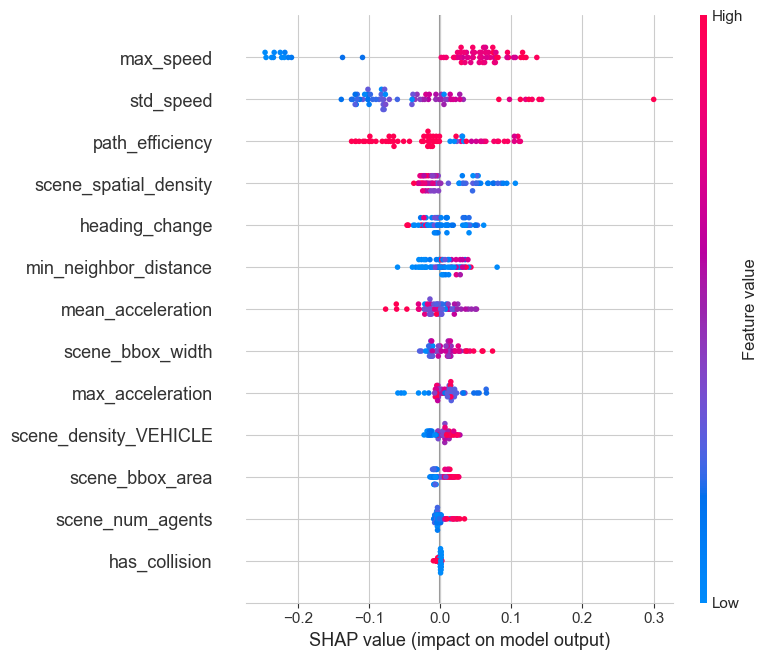

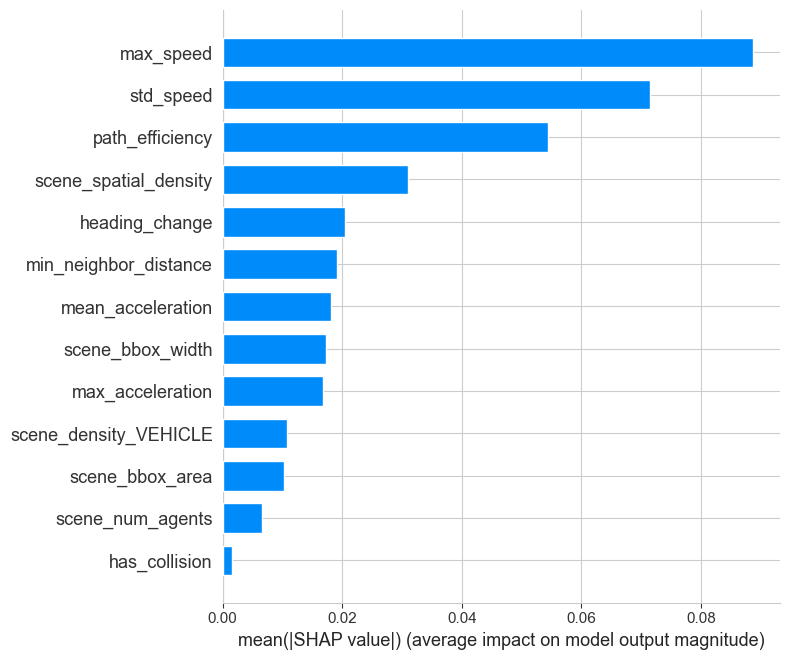

SHAP beeswarm saved to: ../../results/interpretable_model/xgboost/plots/shap_beeswarm_ml_ade_log.png
SHAP bar saved to:      ../../results/interpretable_model/xgboost/plots/shap_bar_ml_ade_log.png


In [8]:
# Build SHAP explanation on test set (native SHAP explainers)
try:
    explainer = shap.Explainer(model, X_train)
    shap_exp = explainer(X_test)
    shap_values = shap_exp.values
except Exception:
    tree_explainer = shap.TreeExplainer(model)
    try:
        shap_exp = tree_explainer(X_test)
        shap_values = shap_exp.values
    except Exception:
        shap_values = tree_explainer.shap_values(X_test)
        if isinstance(shap_values, list):
            shap_values = shap_values[0]

        expected_value = tree_explainer.expected_value
        if isinstance(expected_value, (list, tuple, np.ndarray)):
            expected_value = np.array(expected_value).reshape(-1)[0]

        base_values = np.full(X_test.shape[0], expected_value, dtype=float)
        shap_exp = shap.Explanation(
            values=shap_values,
            base_values=base_values,
            data=X_test.values,
            feature_names=X_test.columns.tolist(),
        )

# Global importance (mean absolute SHAP)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': mean_abs_shap,
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

display(shap_importance_df)

shap_imp_path = TABLES_DIR / f'shap_importance_{target_col}.csv'
shap_importance_df.to_csv(shap_imp_path, index=False)
print(f'SHAP importance table saved to: {shap_imp_path}')

# SHAP beeswarm
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False, max_display=20)
beeswarm_path = PLOTS_DIR / f'shap_beeswarm_{target_col}.png'
plt.tight_layout()
plt.savefig(beeswarm_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# SHAP bar
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, max_display=20)
bar_path = PLOTS_DIR / f'shap_bar_{target_col}.png'
plt.tight_layout()
plt.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print(f'SHAP beeswarm saved to: {beeswarm_path}')
print(f'SHAP bar saved to:      {bar_path}')

Top 6 features by mean |SHAP|:
['max_speed', 'std_speed', 'path_efficiency', 'scene_spatial_density', 'heading_change', 'min_neighbor_distance']


<Figure size 800x500 with 0 Axes>

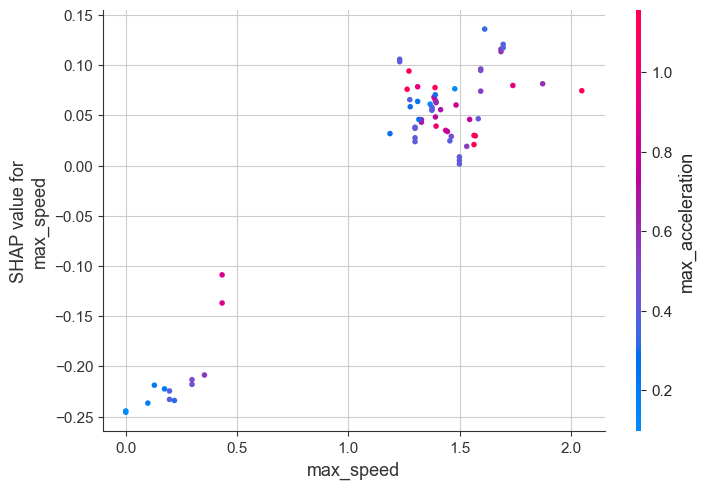

<Figure size 800x500 with 0 Axes>

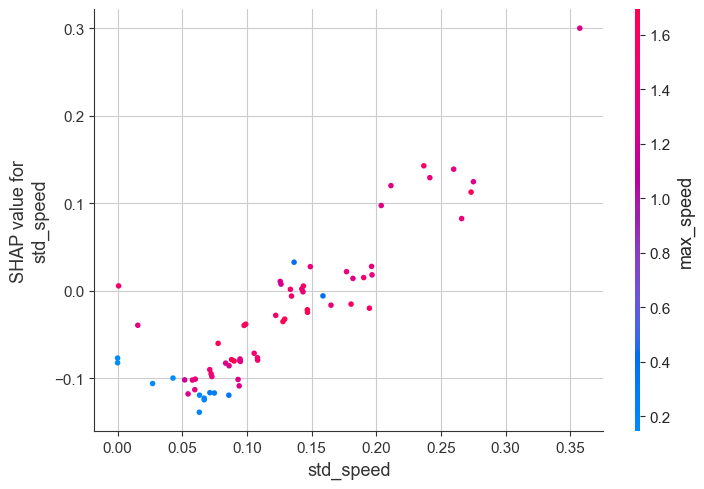

<Figure size 800x500 with 0 Axes>

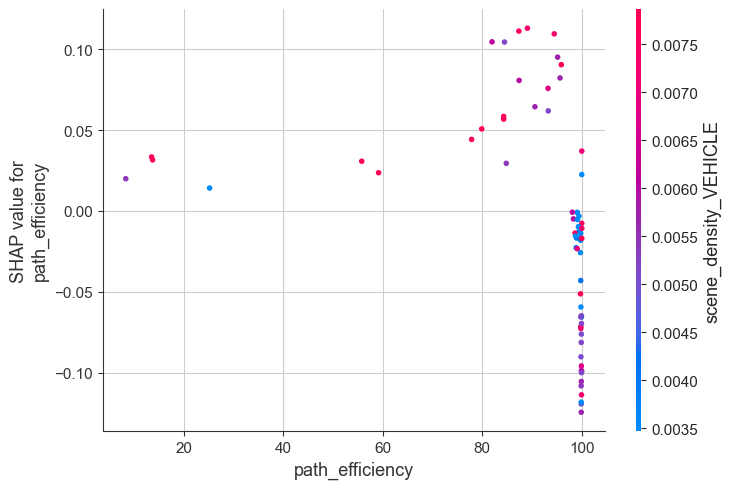

<Figure size 800x500 with 0 Axes>

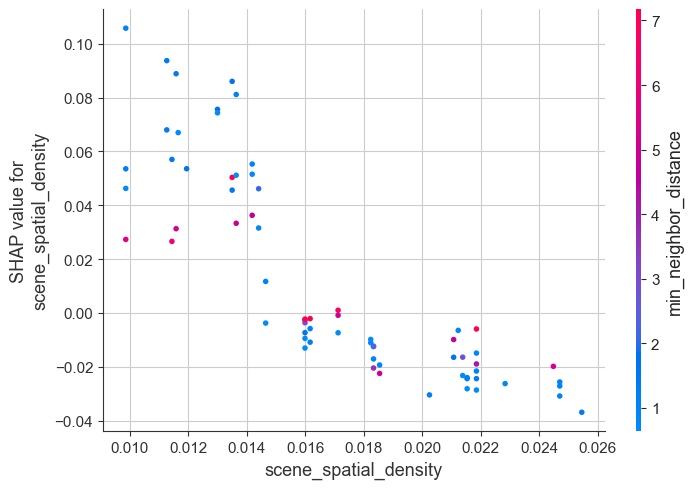

<Figure size 800x500 with 0 Axes>

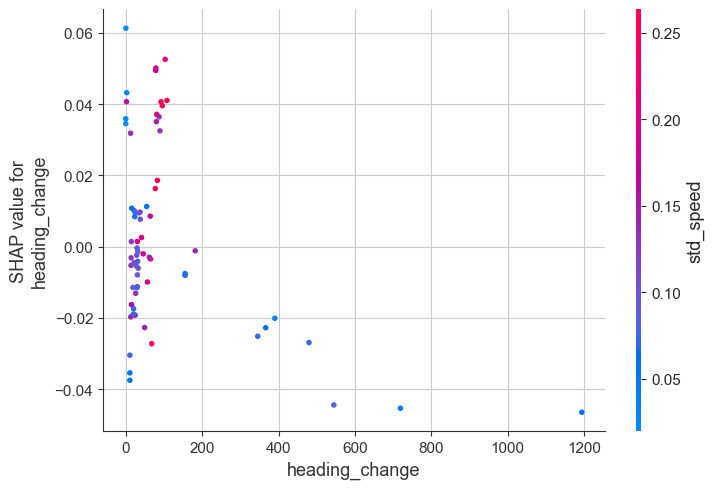

<Figure size 800x500 with 0 Axes>

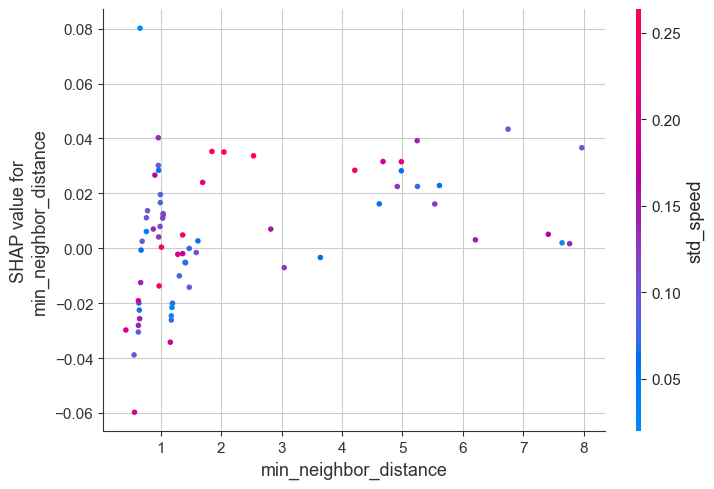

SHAP dependence plots saved for top 6 features.


In [9]:
# SHAP dependence plots for top 6 features
top_features = shap_importance_df['feature'].head(6).tolist()
print('Top 6 features by mean |SHAP|:')
print(top_features)

for feat in top_features:
    plt.figure(figsize=(8, 5))
    shap.dependence_plot(feat, shap_values, X_test, show=False, interaction_index='auto')
    dep_path = PLOTS_DIR / f'shap_dependence_{feat}_{target_col}.png'
    plt.tight_layout()
    plt.savefig(dep_path, dpi=150, bbox_inches='tight')
    plt.show()

print('SHAP dependence plots saved for top 6 features.')

Worst-error sample index (within test set): 25, abs error=0.808040
Best-error sample index (within test set):  55, abs error=0.002208


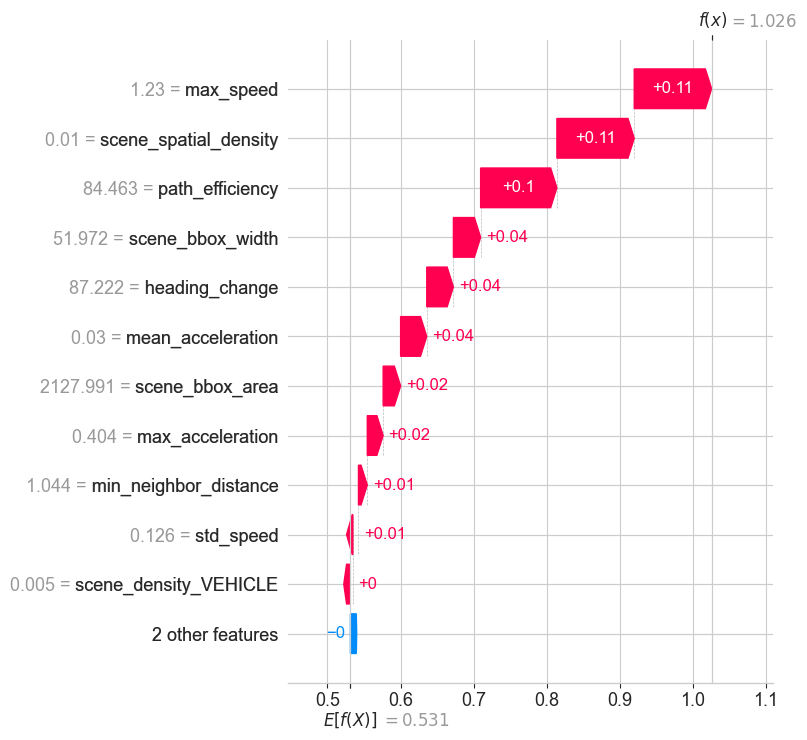

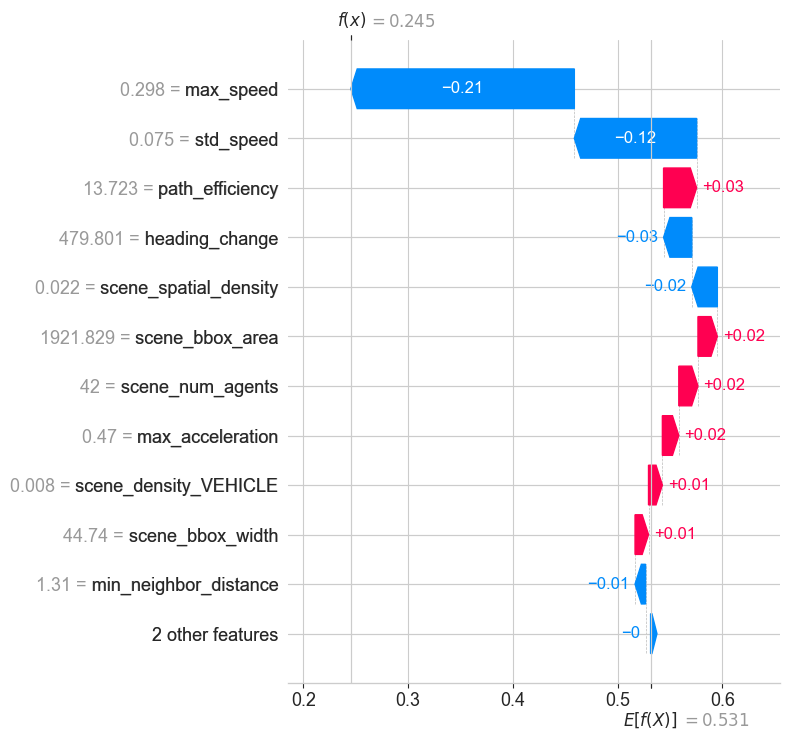

Local SHAP worst-case plot saved to: ../../results/interpretable_model/xgboost/plots/shap_local_worst_ml_ade_log.png
Local SHAP best-case plot saved to:  ../../results/interpretable_model/xgboost/plots/shap_local_best_ml_ade_log.png


In [10]:
# Local SHAP explanations: one worst-error and one best-error test sample
abs_error_test = np.abs(y_test_orig - y_test_pred_orig)
worst_idx = int(np.argmax(abs_error_test))
best_idx = int(np.argmin(abs_error_test))

print(f'Worst-error sample index (within test set): {worst_idx}, abs error={abs_error_test[worst_idx]:.6f}')
print(f'Best-error sample index (within test set):  {best_idx}, abs error={abs_error_test[best_idx]:.6f}')

# Use Explanation object directly (works for both Explainer and TreeExplainer fallback)
shap.plots.waterfall(shap_exp[worst_idx], max_display=12, show=False)
worst_path = PLOTS_DIR / f'shap_local_worst_{target_col}.png'
plt.tight_layout()
plt.savefig(worst_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()

shap.plots.waterfall(shap_exp[best_idx], max_display=12, show=False)
best_path = PLOTS_DIR / f'shap_local_best_{target_col}.png'
plt.tight_layout()
plt.savefig(best_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print(f'Local SHAP worst-case plot saved to: {worst_path}')
print(f'Local SHAP best-case plot saved to:  {best_path}')

## 9. Partial Dependence Plots (Top 6 SHAP Features)

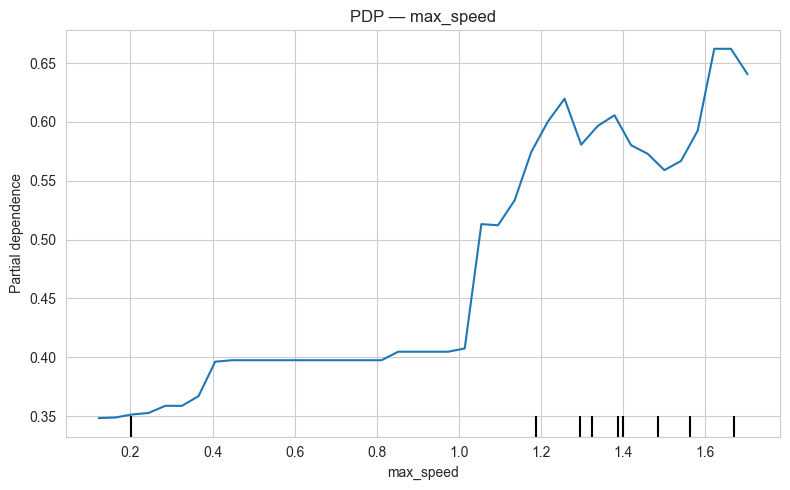

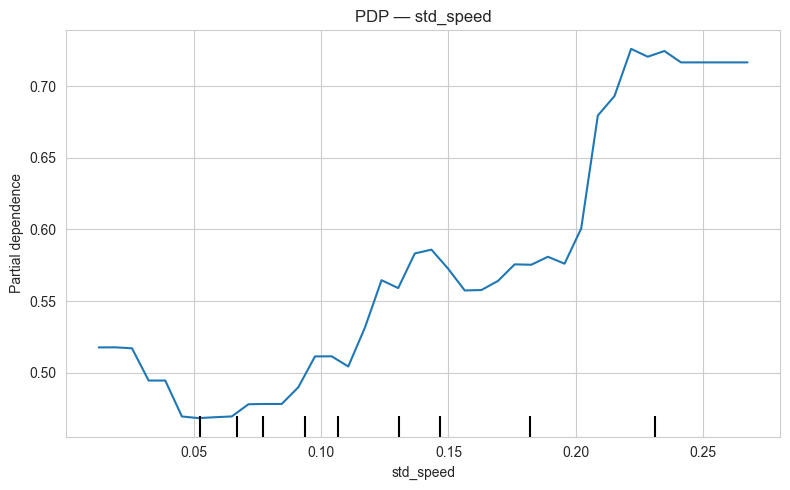

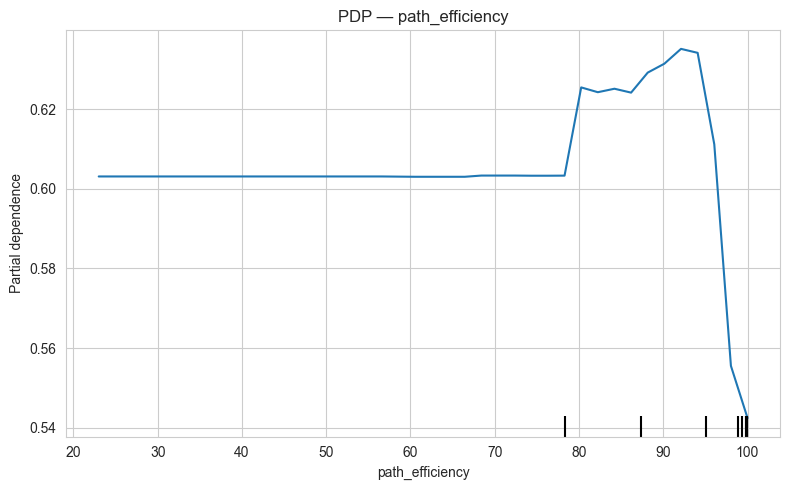

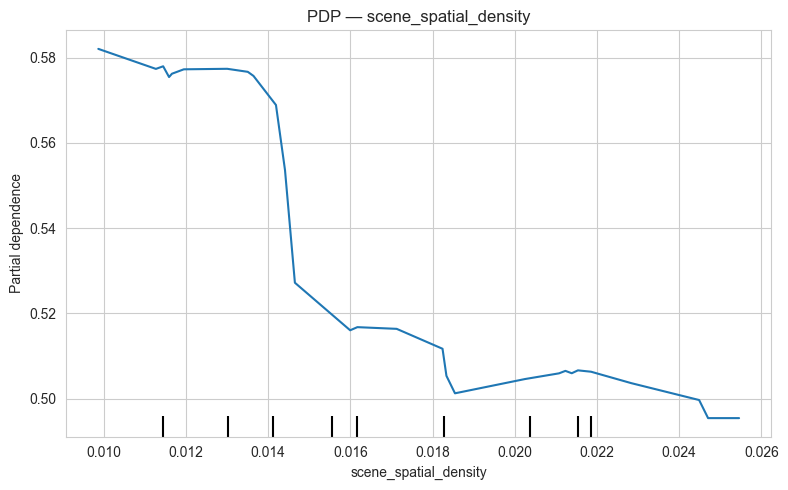

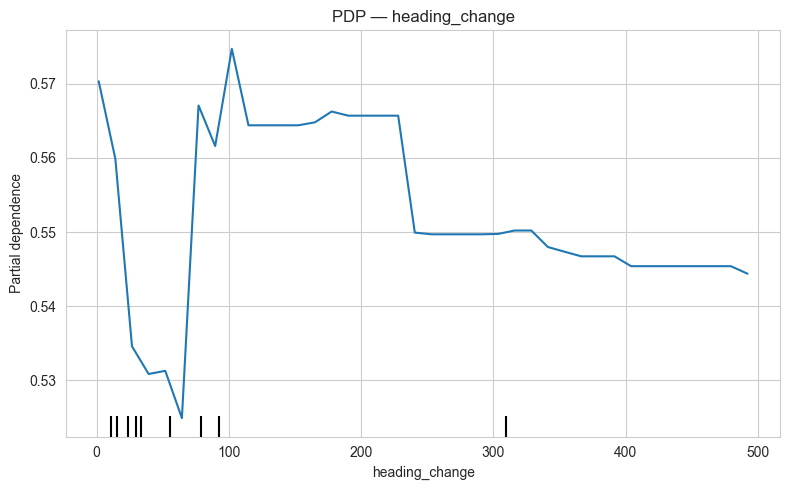

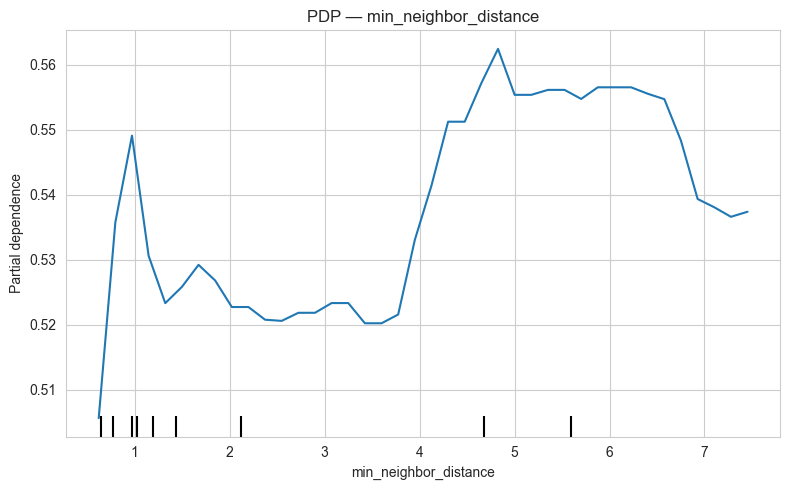

PDP plots saved for top 6 SHAP-ranked features.


In [11]:
for feat in top_features:
    fig, ax = plt.subplots(figsize=(8, 5))
    PartialDependenceDisplay.from_estimator(
        model,
        X_test,
        features=[feat],
        kind='average',
        grid_resolution=40,
        ax=ax,
    )
    ax.set_title(f'PDP — {feat}')
    pdp_path = PLOTS_DIR / f'pdp_{feat}_{target_col}.png'
    plt.tight_layout()
    plt.savefig(pdp_path, dpi=150, bbox_inches='tight')
    plt.show()

print('PDP plots saved for top 6 SHAP-ranked features.')

## 10. Cohort Analysis: Poor vs Well Performance

In [12]:
abs_error_test = np.abs(y_test_orig - y_test_pred_orig)
poor_threshold = np.quantile(abs_error_test, 1.0 - POOR_WELL_QUANTILE)
well_threshold = np.quantile(abs_error_test, POOR_WELL_QUANTILE)

poor_mask = abs_error_test >= poor_threshold
well_mask = abs_error_test <= well_threshold

X_test_reset = X_test.reset_index(drop=True).copy()
X_test_reset['abs_error'] = abs_error_test

poor_df = X_test_reset.loc[poor_mask].copy()
well_df = X_test_reset.loc[well_mask].copy()

print(f'Poor threshold (top {POOR_WELL_QUANTILE:.0%}): abs_error >= {poor_threshold:.6f}')
print(f'Well threshold (bottom {POOR_WELL_QUANTILE:.0%}): abs_error <= {well_threshold:.6f}')
print(f'Poor cohort size: {len(poor_df)}')
print(f'Well cohort size: {len(well_df)}')

Poor threshold (top 20%): abs_error >= 0.300230
Well threshold (bottom 20%): abs_error <= 0.035825
Poor cohort size: 14
Well cohort size: 14


In [13]:
def standardized_difference(a, b, eps=1e-12):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    pooled = np.sqrt((np.var(a, ddof=1) + np.var(b, ddof=1)) / 2.0)
    if not np.isfinite(pooled) or pooled < eps:
        return 0.0
    return (np.mean(a) - np.mean(b)) / pooled

cohort_rows = []
for feat in feature_cols:
    poor_vals = poor_df[feat].dropna().values
    well_vals = well_df[feat].dropna().values

    cohort_rows.append({
        'feature': feat,
        'poor_mean': np.mean(poor_vals),
        'well_mean': np.mean(well_vals),
        'poor_median': np.median(poor_vals),
        'well_median': np.median(well_vals),
        'mean_diff': np.mean(poor_vals) - np.mean(well_vals),
        'median_diff': np.median(poor_vals) - np.median(well_vals),
        'standardized_diff': standardized_difference(poor_vals, well_vals),
    })

cohort_df = pd.DataFrame(cohort_rows)
cohort_df['abs_standardized_diff'] = cohort_df['standardized_diff'].abs()
cohort_df = cohort_df.sort_values('abs_standardized_diff', ascending=False).reset_index(drop=True)

display(cohort_df)

cohort_path = TABLES_DIR / f'cohort_comparison_{target_col}.csv'
cohort_df.to_csv(cohort_path, index=False)
print(f'Cohort comparison table saved to: {cohort_path}')

,feature,poor_mean,well_mean,poor_median,well_median,mean_diff,median_diff,standardized_diff,abs_standardized_diff
0,mean_acceleration,0.043564,0.000747,0.042003,-0.002083,0.042817,0.044086,1.396636,1.396636
1,scene_spatial_density,0.014302,0.019506,0.013916,0.021153,-0.005204,-0.007237,-1.392395,1.392395
2,max_speed,1.441543,0.818867,1.393874,0.848262,0.622676,0.545612,1.384864,1.384864
3,scene_num_agents,19.071429,29.785714,19.000000,22.500000,-10.714286,-3.500000,-1.129075,1.129075
4,path_efficiency,93.216544,70.123346,93.240837,91.568540,23.093199,1.672298,0.848175,0.848175
5,heading_change,58.736573,268.114609,72.670197,71.453077,-209.378036,1.217120,-0.843131,0.843131
6,std_speed,0.168052,0.106241,0.160308,0.073832,0.061810,0.086476,0.828430,0.828430
7,max_acceleration,0.648033,0.525336,0.588480,0.410601,0.122697,0.177879,0.386665,0.386665
8,scene_density_VEHICLE,0.005601,0.006289,0.005423,0.006643,-0.000688,-0.001219,-0.372474,0.372474
9,min_neighbor_distance,2.184730,2.646821,1.325350,1.439162,-0.462090,-0.113812,-0.207100,0.207100


Cohort comparison table saved to: ../../results/interpretable_model/xgboost/tables/cohort_comparison_ml_ade_log.csv


Top differentiating features (|standardized_diff|):
['mean_acceleration', 'scene_spatial_density', 'max_speed', 'scene_num_agents', 'path_efficiency', 'heading_change']


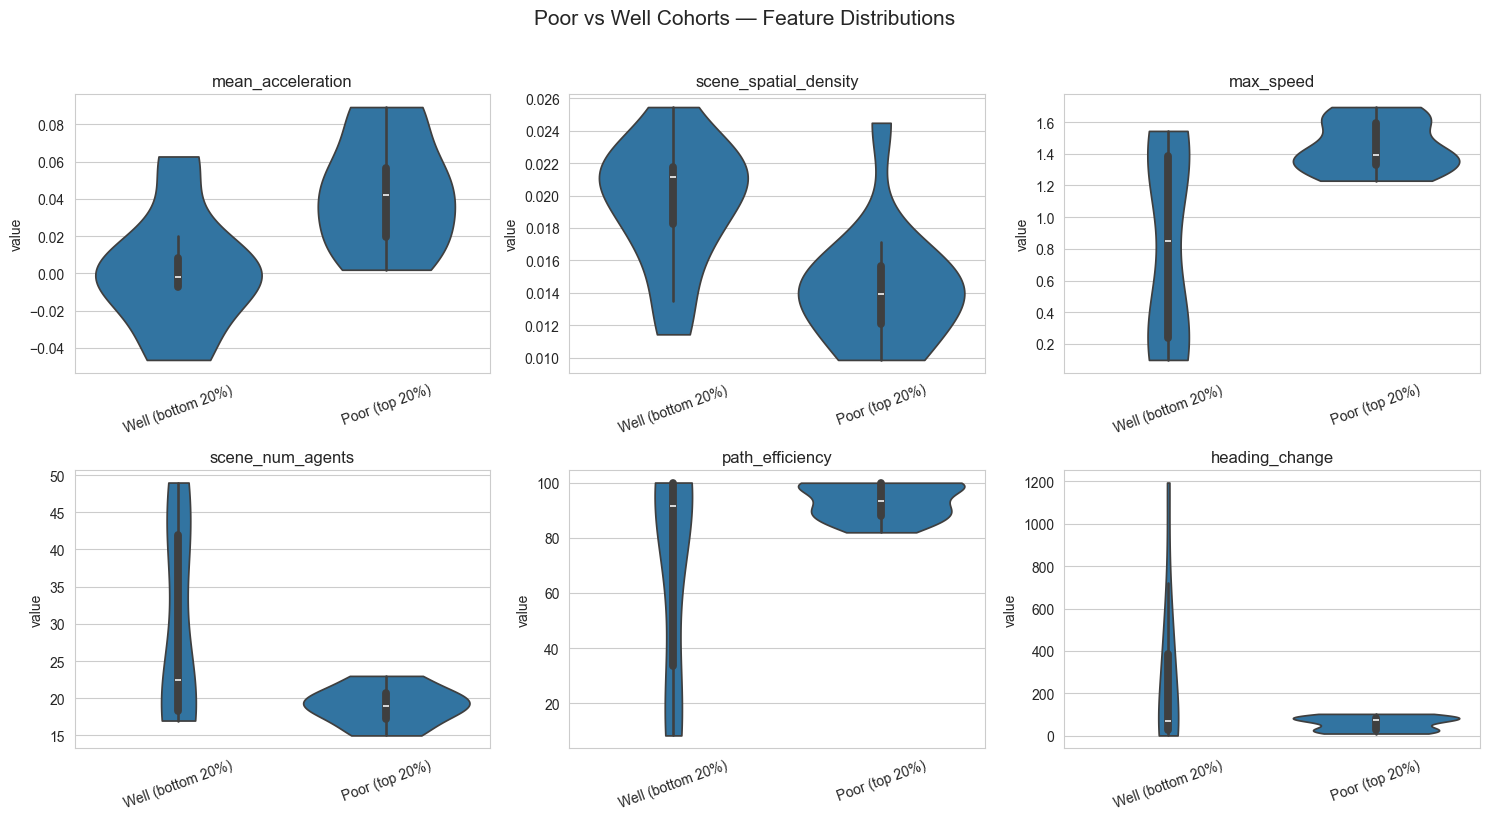

Cohort violin plots saved to: ../../results/interpretable_model/xgboost/plots/cohort_violin_top_features_ml_ade_log.png


In [14]:
# Violin plots for top differentiating features
top_diff_features = cohort_df['feature'].head(6).tolist()
print('Top differentiating features (|standardized_diff|):')
print(top_diff_features)

n_plot = len(top_diff_features)
n_cols = 3
n_rows = int(np.ceil(n_plot / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, feat in enumerate(top_diff_features):
    long_df = pd.concat([
        pd.DataFrame({'cohort': 'Well (bottom 20%)', 'value': well_df[feat].values}),
        pd.DataFrame({'cohort': 'Poor (top 20%)', 'value': poor_df[feat].values}),
    ], ignore_index=True)

    sns.violinplot(data=long_df, x='cohort', y='value', ax=axes[i], inner='box', cut=0)
    axes[i].set_title(feat)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=20)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Poor vs Well Cohorts — Feature Distributions', fontsize=15, y=1.02)
plt.tight_layout()
cohort_plot_path = PLOTS_DIR / f'cohort_violin_top_features_{target_col}.png'
plt.savefig(cohort_plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Cohort violin plots saved to: {cohort_plot_path}')

## 11. Sanity Checks and Final Summary

In [15]:
# Sanity check 1: poor median error > well median error
poor_median_error = np.median(abs_error_test[poor_mask])
well_median_error = np.median(abs_error_test[well_mask])
print(f'Poor median abs error: {poor_median_error:.6f}')
print(f'Well median abs error: {well_median_error:.6f}')
print(f'Check poor > well: {poor_median_error > well_median_error}')

# Sanity check 2: overlap between top SHAP and top cohort-difference features
top_shap = set(shap_importance_df['feature'].head(6).tolist())
top_cohort = set(cohort_df['feature'].head(6).tolist())
overlap = top_shap.intersection(top_cohort)

print(f'Top SHAP features:   {sorted(top_shap)}')
print(f'Top cohort features: {sorted(top_cohort)}')
print(f'Overlap ({len(overlap)}): {sorted(overlap)}')

print('\nSaved artifacts:')
print(f'- Metrics table:          {metrics_path}')
print(f'- SHAP importance table:  {shap_imp_path}')
print(f'- Cohort comparison:      {cohort_path}')
print(f'- Plot directory:         {PLOTS_DIR}')

Poor median abs error: 0.474816
Well median abs error: 0.022288
Check poor > well: True
Top SHAP features:   ['heading_change', 'max_speed', 'min_neighbor_distance', 'path_efficiency', 'scene_spatial_density', 'std_speed']
Top cohort features: ['heading_change', 'max_speed', 'mean_acceleration', 'path_efficiency', 'scene_num_agents', 'scene_spatial_density']
Overlap (4): ['heading_change', 'max_speed', 'path_efficiency', 'scene_spatial_density']

Saved artifacts:
- Metrics table:          ../../results/interpretable_model/xgboost/tables/metrics_ml_ade_log.csv
- SHAP importance table:  ../../results/interpretable_model/xgboost/tables/shap_importance_ml_ade_log.csv
- Cohort comparison:      ../../results/interpretable_model/xgboost/tables/cohort_comparison_ml_ade_log.csv
- Plot directory:         ../../results/interpretable_model/xgboost/plots
